# **Data Preparation**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
file_name= "../dm1_25_26_dataset/DM1_game_dataset.csv"
df = pd.read_csv(file_name)

#### Correlation matrix before cleaning 

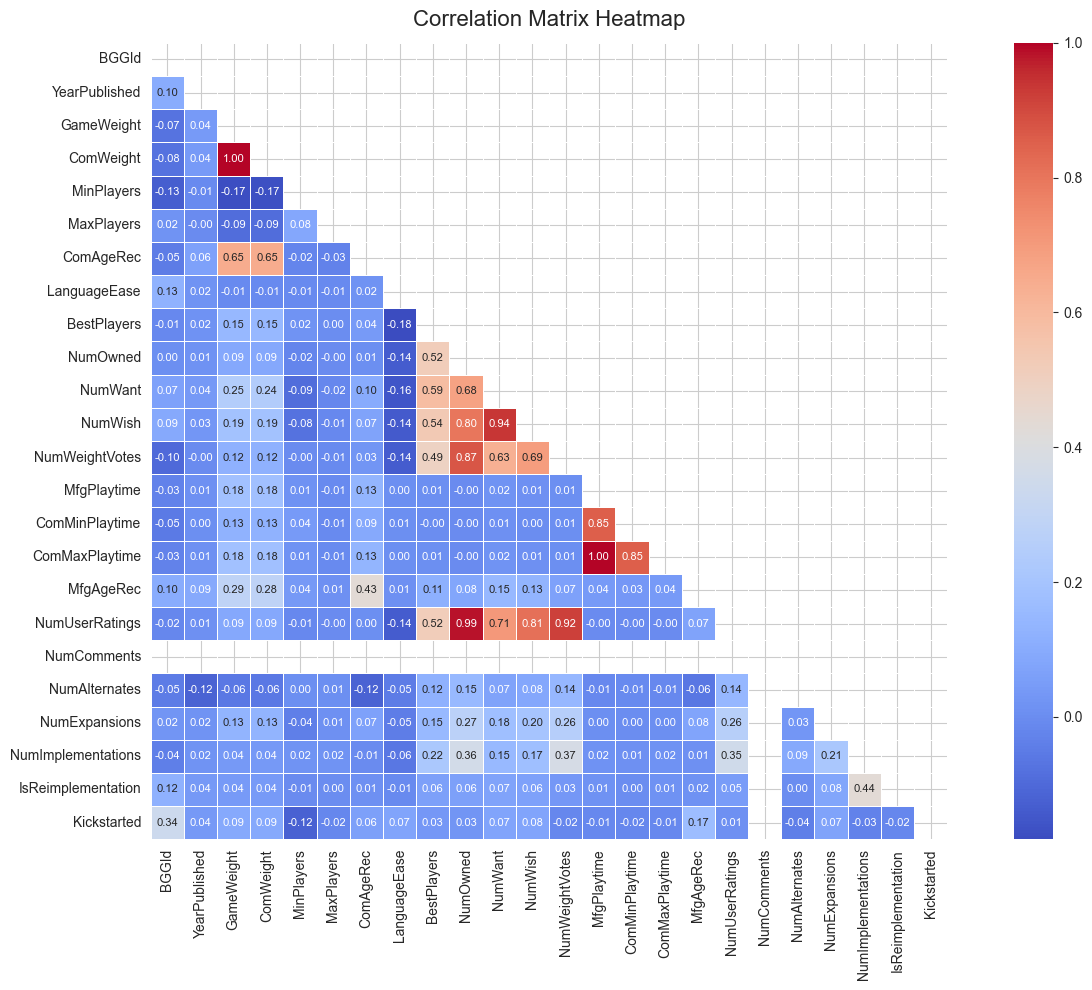

In [3]:
# 1. Select all numeric columns
numeric_df = df.select_dtypes(include="number")

# 2. Automatically exclude ALL columns starting with 'Cat:' or 'Rank:'
cols_to_drop = [c for c in numeric_df.columns if c.startswith("Cat:") or c.startswith("Rank:")]
numeric_df = numeric_df.drop(columns=cols_to_drop)

# 3. Calculate correlation matrix
corr_matrix = numeric_df.corr()

# 4. Generate a mask for the upper triangle
# This hides the redundant part of the matrix (the diagonal and the mirrored side)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Plot the heatmap
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix Heatmap", fontsize=16, pad=12)
plt.tight_layout()
plt.show()

#### Remove the following features we selected in the data understanding part:

- **Description**: it's a textual feature so we don't need it for our analysis
- **BestPlayers**: contains more than 90% of 0s
- **GoodPlayers**: contains more than 90% of empty arrays
- **NumComments**: contains 100% of 0s
- **ImagePath**: contains urls (not relevant)
- **MfgPlaytime**: 1.0 correlation with ComMaxPlaytime
- **Family**: contains almost 70% of missing values

In [4]:
df = df.drop(["Description", "BestPlayers", "GoodPlayers", "NumComments", "ImagePath","MfgPlaytime", "Family"], axis=1)
df.head()

,BGGId,Name,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,NumOwned,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,2014,1.8333,2.0512,2,4,8.0,213.0,528,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,2021,1.0000,1.2256,2,5,8.0,36.0,72,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,2020,3.6667,3.8190,1,5,NaN,NaN,834,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,2004,1.3077,1.4216,2,2,7.0,NaN,154,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,2019,1.5000,1.6230,2,4,NaN,7.0,208,...,21926,0,0,0,0,0,0,0,0,Medium


####  Label encoding: replace 'low', 'medium', 'high' values in **Rating** with 1, 2, 3

In [5]:
rating_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Rating'] = df['Rating'].map(rating_map)
df['Rating']

0        1
1        2
2        3
3        1
4        2
        ..
21920    1
21921    2
21922    1
21923    3
21924    1
Name: Rating, Length: 21925, dtype: int64

#### Filter **'YearPublished'** by removing games published before 1950

In [6]:
# count how many rows have 'YearPublished' before 1950
df_1950 = df[(df['YearPublished'] >= 1950)]
print(f"Number of rows with 'YearPublished' before 1950: {len(df)-len(df_1950)}")

Number of rows with 'YearPublished' before 1950: 406


In [7]:
# drop rows where 'YearPublished' is before 1950
df = df[df['YearPublished'] >= 1950]
df['YearPublished']

0        2014
1        2021
2        2020
3        2004
4        2019
         ... 
21920    1998
21921    2004
21922    1993
21923    2015
21924    1989
Name: YearPublished, Length: 21519, dtype: int64

#### Handling outliers and logical inconsistencies in **'ComMinPlaytime'** and **'ComMaxPlaytime'**

In [8]:
# Define target columns and category columns
playtime_cols = ["ComMinPlaytime", "ComMaxPlaytime"]
for col in playtime_cols:
    df[col] = df[col].astype(float)
    
cat_cols = [col for col in df.columns if col.startswith('Cat:')]

In [9]:
# If Min > Max, drop the rows
index_to_drop = df[df['ComMinPlaytime'] > df['ComMaxPlaytime']].index
df.drop(index=index_to_drop, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Removed rows: {len(index_to_drop)}")
print(f"Remaining rows: {len(df)}")

Removed rows: 150
Remaining rows: 21369


In [10]:
# Outlier removal
for col in playtime_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    upper_bound = Q3 + 5.0 * IQR
    # Lower bound for playtime is usually just 0, so we focus on the upper tail
    
    initial_len = len(df)
    df = df[df[col] <= upper_bound].copy().reset_index(drop=True)
    print(f"Removed {initial_len - len(df)} outliers from {col} (Threshold: {upper_bound:.2f})")

Removed 517 outliers from ComMinPlaytime (Threshold: 260.00)
Removed 200 outliers from ComMaxPlaytime (Threshold: 390.00)


In [11]:
# Category-based imputation
# Calculate global medians on positive values as fallback
global_medians = {col: df[df[col] > 0][col].median() for col in playtime_cols}

# Pre-calculate medians per category (ignoring zeros)
medians_map = {col: {} for col in playtime_cols}

for col in playtime_cols:
    for cat in cat_cols:
        subset = df[(df[cat] == 1) & (df[col] > 0)][col]
        med = subset.median()
        if not pd.isna(med):
            medians_map[col][cat] = med

def get_imputation_value(row, col_name):
    active_cats = [cat for cat in cat_cols if row[cat] == 1]
    cat_medians = [medians_map[col_name][cat] for cat in active_cats if cat in medians_map[col_name]]
    if cat_medians:
        return np.mean(cat_medians)
    else:
        return global_medians[col_name]

# Apply to double zeros
mask_double_zero = (df['ComMinPlaytime'] == 0.0) & (df['ComMaxPlaytime'] == 0.0)
print(f"Imputing {mask_double_zero.sum()} rows...")

for col in playtime_cols:
    df.loc[mask_double_zero, col] = df[mask_double_zero].apply(
        lambda row: get_imputation_value(row, col), axis=1
    )

# --- 4. FINAL SKEWNESS CALCULATION ---
print("\nFINAL SKEWNESS AFTER CLEANING & IMPUTATION")
print(f"Final Skewness ComMinPlaytime: {df['ComMinPlaytime'].skew():.4f}")
print(f"Final Skewness ComMaxPlaytime: {df['ComMaxPlaytime'].skew():.4f}")

Imputing 593 rows...

FINAL SKEWNESS AFTER CLEANING & IMPUTATION
Final Skewness ComMinPlaytime: 2.0662
Final Skewness ComMaxPlaytime: 2.0010


Statistics after cleaning:
       ComMinPlaytime  ComMaxPlaytime
count    20652.000000    20652.000000
mean        50.815781       63.332316
std         46.535172       55.944708
min          0.000000        1.000000
25%         20.000000       30.000000
50%         30.000000       45.000000
75%         60.000000       90.000000
max        250.000000      360.000000


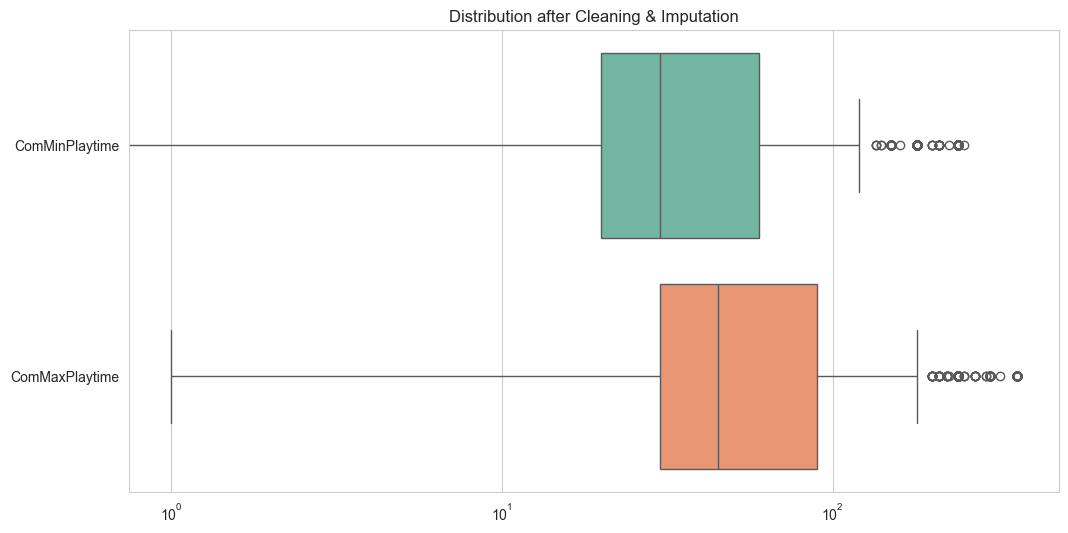

In [12]:
# Statistical summary
print("Statistics after cleaning:")
print(df[playtime_cols].describe())

# Visual check
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[playtime_cols], orient="h", palette="Set2")
plt.title(f"Distribution after Cleaning & Imputation")
plt.xscale('log') # Log scale to better visualize the range
plt.show()

In [13]:
# 1. Calcolo numerico della Skewness originale
skew_com_min = df['ComMinPlaytime'].skew()
skew_com_max = df['ComMaxPlaytime'].skew()

print(f"--- ANALISI SKEWNESS ORIGINALE ---")
print(f"ComMinPlaytime: {skew_com_min:.4f}")
print(f"ComMaxPlaytime: {skew_com_max:.4f}")


--- ANALISI SKEWNESS ORIGINALE ---
ComMinPlaytime: 2.0662
ComMaxPlaytime: 2.0010


#### Merging of '**NumWant**', '**NumOwned**' and '**NumWish**' features 

In [14]:
df['Avg_popularity'] = (df['NumWant'] + df['NumWish'] + df['NumOwned']) / 3

In [15]:
df[['Avg_popularity','NumWant','NumWish','NumOwned']]

,Avg_popularity,NumWant,NumWish,NumOwned
0,199.333333,6,64,528
1,43.666667,12,47,72
2,311.333333,37,63,834
3,54.333333,2,7,154
4,82.333333,4,35,208
...,...,...,...,...
20647,40.333333,10,29,82
20648,104.666667,37,67,210
20649,82.666667,5,8,235
20650,634.333333,123,374,1406


In [16]:
df = df.drop(['NumWant','NumWish','NumOwned'], axis=1)

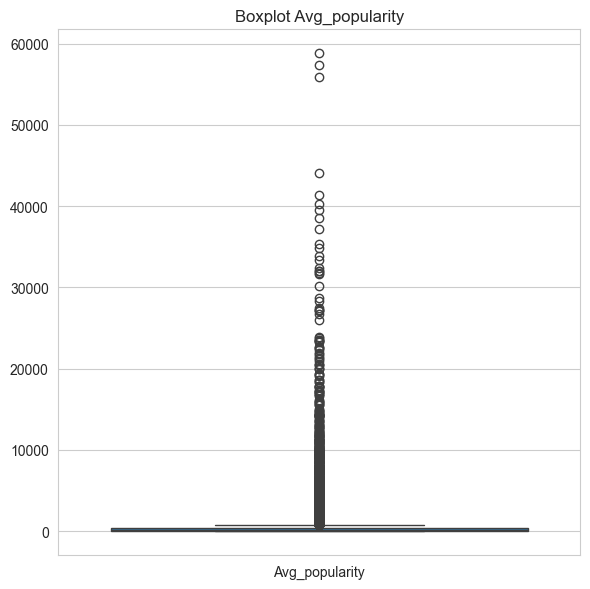

In [17]:
# outlier detection for Avg_popularity
plt.figure(figsize=(6, 6))
sns.boxplot(data=df[["Avg_popularity"]])
plt.title("Boxplot Avg_popularity")
plt.tight_layout()
plt.show()

In [18]:
df["Avg_popularity"].describe()

count    20652.000000
mean       594.035767
std       2049.589184
min          2.000000
25%         60.000000
50%        128.333333
75%        367.666667
max      58817.000000
Name: Avg_popularity, dtype: float64

In [19]:
df["Avg_popularity_log"] = np.log1p(df["Avg_popularity"])
df.drop("Avg_popularity", axis=1, inplace=True)

In [20]:
df["Avg_popularity_log"].describe()

count    20652.000000
mean         5.121725
std          1.361944
min          1.098612
25%          4.110874
50%          4.862393
75%          5.909893
max         10.982203
Name: Avg_popularity_log, dtype: float64

#### Dropping **ComWeight** bc of extremely high correlation (almost 1) with **GameWeight**

In [21]:
df = df.drop(['ComWeight'], axis=1)

#### Dropping **'LanguageEase'** 

In [22]:
#dropping LanguageEase because of semantic descrepancy between variable description and actual data
# + 26% of missing values
df = df.drop(['LanguageEase'], axis=1)

#### Dropping **'GameWeight'** Zero values (range is 1-5)

In [23]:
# drop rows with 0 in 'GameWeight' as they are likely missing data
df = df[df['GameWeight'] != 0]
df.reset_index(drop=True, inplace=True)
#print the number of removed rows
print(f"Number of removed rows: {len(index_to_drop)}")


Number of removed rows: 150


#### Handling logical inconsistencies and Zero values in **'MinPlayers'** and **'MaxPlayers'**

In [24]:
df[["MinPlayers","MaxPlayers"]].describe()

,MinPlayers,MaxPlayers
count,20177.000000,20177.000000
mean,2.008871,5.684988
std,0.686963,15.232014
min,0.000000,0.000000
25%,2.000000,4.000000
50%,2.000000,4.000000
75%,2.000000,6.000000
max,10.000000,999.000000


In [25]:
# Save the initial count to calculate how many rows are removed
initial_count = len(df)
# Drop rows where MinPlayers > MaxPlayers
df = df[df['MinPlayers'] <= df['MaxPlayers']].copy()
# Reset index to ensure a clean dataframe
df.reset_index(drop=True, inplace=True)
# Calculate and print the number of removed rows
removed_rows = initial_count - len(df)
print(f"Number of removed rows (Min > Max): {removed_rows}")

Number of removed rows (Min > Max): 101


In [26]:
# 1. Count rows where both MinPlayers and MaxPlayers are zero
mask_players_zero = (df['MinPlayers'] == 0) & (df['MaxPlayers'] == 0)
zero_count = mask_players_zero.sum()

# 2. Calculate initial skewness
initial_skew_min = df['MinPlayers'].skew()
initial_skew_max = df['MaxPlayers'].skew()

print(f"Rows with both MinPlayers and MaxPlayers at zero: {zero_count}")
print(f"Initial Skewness MinPlayers: {initial_skew_min:.4f}")
print(f"Initial Skewness MaxPlayers: {initial_skew_max:.4f}")

Rows with both MinPlayers and MaxPlayers at zero: 31
Initial Skewness MinPlayers: 1.6234
Initial Skewness MaxPlayers: 43.7386


In [27]:
# 1. Remove the 31 rows with double zeros (cleaner than imputing so few rows)
initial_len = len(df)
df = df[~((df['MinPlayers'] == 0) & (df['MaxPlayers'] == 0))].copy().reset_index(drop=True)
print(f"Cleaned: Removed {initial_len - len(df)} rows with double zeros.")

# 2. Outlier Removal ONLY for MaxPlayers (the one with 43.73 skewness)
print("\n--- REMOVING OUTLIERS ONLY FOR MaxPlayers (IQR * 5.0) ---")

col = 'MaxPlayers'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 5.0 * IQR

pre_outlier_len = len(df)
df = df[df[col] <= upper_bound].copy().reset_index(drop=True)

print(f"Removed {pre_outlier_len - len(df)} outliers from {col}.")
print(f"Threshold used: {upper_bound:.2f}")

# 3. Final Skewness Check
print(f"Final Skewness MinPlayers: {df['MinPlayers'].skew():.4f} (Untouched)")
print(f"Final Skewness MaxPlayers: {df['MaxPlayers'].skew():.4f} (Filtered)")

Cleaned: Removed 31 rows with double zeros.

--- REMOVING OUTLIERS ONLY FOR MaxPlayers (IQR * 5.0) ---
Removed 316 outliers from MaxPlayers.
Threshold used: 16.00
Final Skewness MinPlayers: 1.0910 (Untouched)
Final Skewness MaxPlayers: 1.2930 (Filtered)


In [28]:
df[["MinPlayers","MaxPlayers"]].describe()

,MinPlayers,MaxPlayers
count,19729.000000,19729.000000
mean,1.996148,4.646561
std,0.638538,2.181989
min,0.000000,1.000000
25%,2.000000,4.000000
50%,2.000000,4.000000
75%,2.000000,6.000000
max,8.000000,16.000000


In [29]:
remaining_zeros_min = (df['MinPlayers'] == 0).sum()
print(f"Remaining zeros in MinPlayers: {remaining_zeros_min}")

Remaining zeros in MinPlayers: 8


In [30]:
# cat-based imputation for residual zeros in MinPlayers

# Ensure the column is float to avoid warnings
df['MinPlayers'] = df['MinPlayers'].astype(float)

# 1. Check how many zeros we have
mask_min_zero = (df['MinPlayers'] == 0)
print(f"Initial zeros in MinPlayers: {mask_min_zero.sum()}")

# 2. Reuse or Recalculate medians (excluding zeros)
# We focus on MinPlayers only as requested
min_player_medians = {}
global_min_median = df[df['MinPlayers'] > 0]['MinPlayers'].median()

for cat in cat_cols:
    subset = df[(df[cat] == 1) & (df['MinPlayers'] > 0)]['MinPlayers']
    med = subset.median()
    if not pd.isna(med):
        min_player_medians[cat] = med

# 3. Dedicated Helper function
def fill_min_players(row):
    active_cats = [cat for cat in cat_cols if row[cat] == 1]
    cat_medians = [min_player_medians[cat] for cat in active_cats if cat in min_player_medians]
    
    if cat_medians:
        return np.mean(cat_medians)
    else:
        return global_min_median

# 4. Apply imputation ONLY to the remaining zeros
df.loc[mask_min_zero, 'MinPlayers'] = df[mask_min_zero].apply(fill_min_players, axis=1)

# --- 4. FINAL VERIFICATION ---
print(f"Zeros remaining in MinPlayers: {(df['MinPlayers'] == 0).sum()}")
print(f"Final Skewness MinPlayers: {df['MinPlayers'].skew():.4f}")
print(f"New Minimum of MinPlayers: {df['MinPlayers'].min()}")

Initial zeros in MinPlayers: 8


Zeros remaining in MinPlayers: 0
Final Skewness MinPlayers: 1.1062
New Minimum of MinPlayers: 1.0


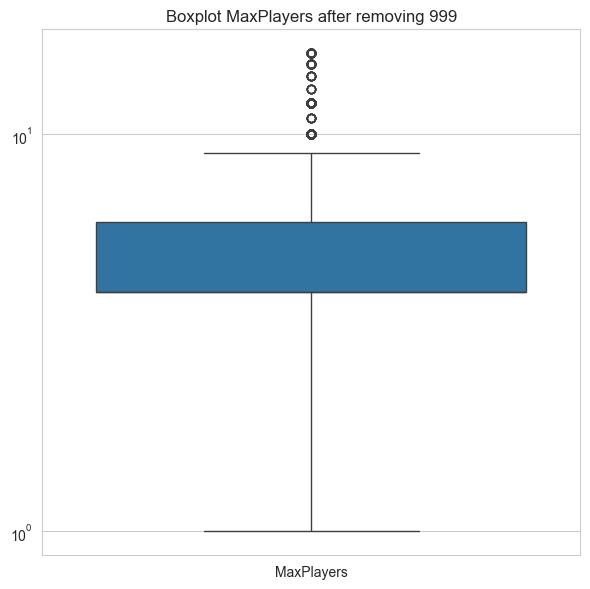

In [31]:
#boxplot of 'MaxPlayers' after removing outliers using a log scale
plt.figure(figsize=(6, 6))
sns.boxplot(data=df[["MaxPlayers"]])
plt.title("Boxplot MaxPlayers after removing 999")
plt.yscale('log')
plt.tight_layout()
plt.show()

In [32]:
# turn "MinPlayers" and "MaxPlayers" to integer
df['MinPlayers'] = df['MinPlayers'].astype(int)
df['MaxPlayers'] = df['MaxPlayers'].astype(int)

#### Handling ZeroValues in **'ComAgeRec'** and **'MfgAgeRec'** and dropping the 2nd one

In [33]:
# Count the zeros in the ComAgeRec column
zeros_ComAgeRec = df['ComAgeRec'].value_counts().get(0, 0)

# Count the zeros in the MfgAgeRec column
zeros_MfgAgeRec = df['MfgAgeRec'].value_counts().get(0, 0)

print(f"Number of 0s in 'ComAgeRec': {zeros_ComAgeRec}")
print(f"Number of 0s in 'MfgAgeRec': {zeros_MfgAgeRec}")

corr = df[['ComAgeRec', 'MfgAgeRec']].corr().iloc[0, 1]            #compute correlation before
print(f"Correlation before transforming 0s in NaN: {corr:.4f}")


Number of 0s in 'ComAgeRec': 0
Number of 0s in 'MfgAgeRec': 1061
Correlation before transforming 0s in NaN: 0.4449


In [34]:
# replacing 0 values with NaN
df["MfgAgeRec"] = df["MfgAgeRec"].replace(0, np.nan)
corr = df[['ComAgeRec', 'MfgAgeRec']].corr().iloc[0, 1]            #compute correlation after
print(f"Correlation after transforming 0s in NaN {corr:.4f}")

Correlation after transforming 0s in NaN 0.7150


In [35]:
# dropping MfgAgeRec
df = df.drop(['MfgAgeRec'], axis=1)

#### Changing 21926 value of **Rank features** in a score (1/rank)

In [36]:
rank_columns_list = [
    'Rank:strategygames', 'Rank:abstracts', 'Rank:familygames',
    'Rank:thematic', 'Rank:cgs', 'Rank:wargames', 
    'Rank:partygames', 'Rank:childrensgames'
]
OUTLIER_VALUE = 21926 

for col in [c for c in rank_columns_list if c in df.columns]:
    valid_mask = df[col] < OUTLIER_VALUE
    df[col] = np.where(valid_mask, 1.0 / df[col], 0.0)
    df.rename(columns={col: col.replace('Rank:', 'Score_')}, inplace=True)

print("Rank transformation complete.")

Rank transformation complete.


### **Correlation heatmap** (for numerical features only)

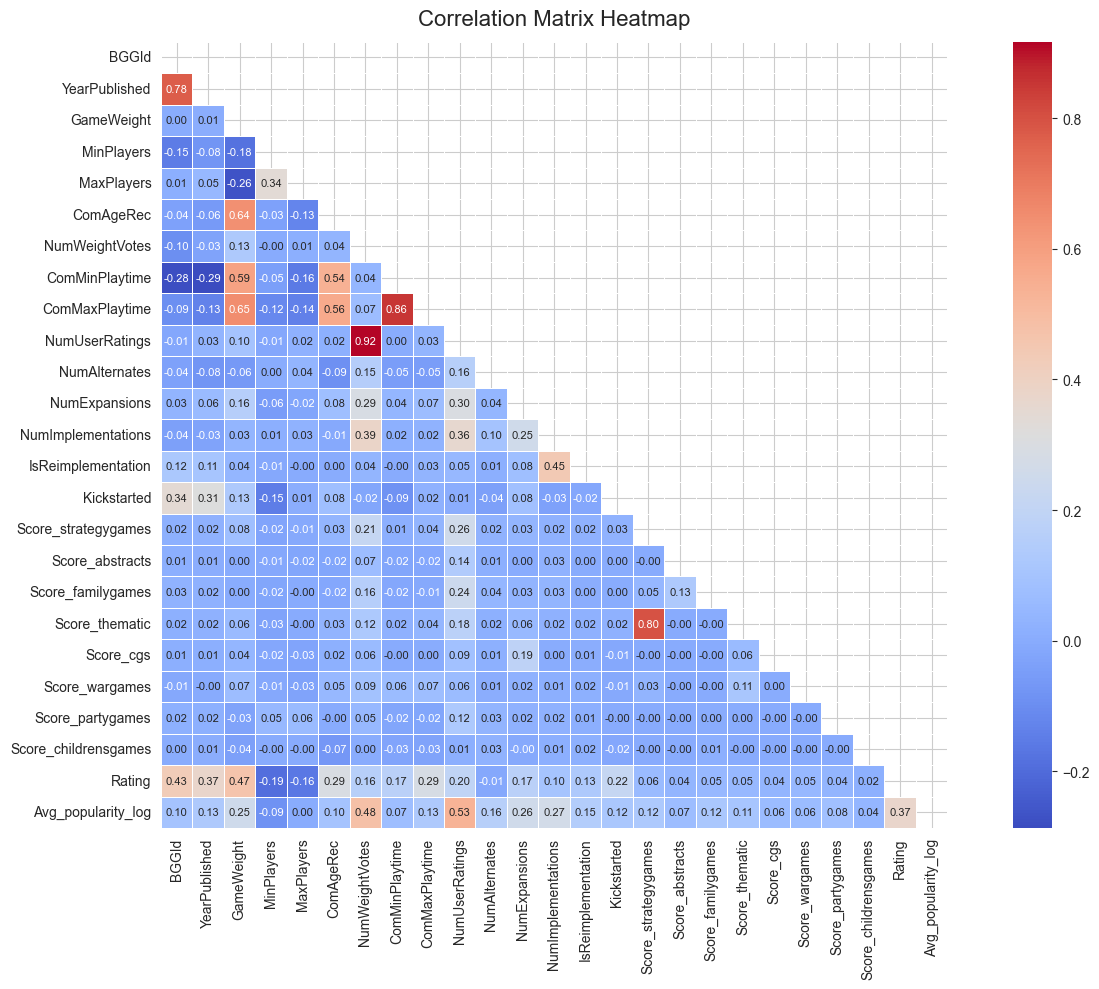

In [37]:
# 1. Select all numeric columns
numeric_df = df.select_dtypes(include="number")

# 2. Automatically exclude ALL columns starting with 'Cat:' or 'Rank:'
cols_to_drop = [c for c in numeric_df.columns if c.startswith("Cat:") or c.startswith("Rank:")]
numeric_df = numeric_df.drop(columns=cols_to_drop)

# 3. Calculate correlation matrix
corr_matrix = numeric_df.corr()

# 4. Generate a mask for the upper triangle
# This hides the redundant part of the matrix (the diagonal and the mirrored side)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Plot the heatmap
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix Heatmap", fontsize=16, pad=12)
plt.tight_layout()
plt.show()

#### **NumAlternates, NumImplementations** and **NumExpansions**

In [38]:
ecosystem_cols = ['NumAlternates', 'NumImplementations', 'NumExpansions']

stats_list = []
for col in ecosystem_cols:
    stats_list.append({
        'Variable': col,
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Max': df[col].max(),
        'Skewness': df[col].skew(),
        'Zero_Rate_%': (df[col] == 0).mean() * 100,
        'Outliers_IQR_1.5': (df[col] > (df[col].quantile(0.75) + 1.5 * (df[col].quantile(0.75) - df[col].quantile(0.25)))).sum()
    })

stats_df = pd.DataFrame(stats_list)
print(stats_df.to_string(index=False))

          Variable     Mean  Median  Max  Skewness  Zero_Rate_%  Outliers_IQR_1.5
     NumAlternates 1.396067     0.0  850 81.928494    58.999442              3119
NumImplementations 0.304425     0.0   38 12.508525    77.895484              4361
     NumExpansions 1.399564     0.0  254 14.421402    73.607380              2047


In [39]:
# Apply log transformation (log1p handles zeros: log(1+0) = 0)
for col in ecosystem_cols:
    new_col_name = f"{col}_log"
    df[new_col_name] = np.log1p(df[col])
    
    # Calculate skewness improvement
    old_skew = df[col].skew()
    new_skew = df[new_col_name].skew()
    
    print(f"Transforming {col}:")
    print(f"  - Original Skewness: {old_skew:.2f}")
    print(f"  - Log-Transformed Skewness: {new_skew:.2f}")
    print(f"  - New Maximum Value: {df[new_col_name].max():.2f}\n")

Transforming NumAlternates:
  - Original Skewness: 81.93
  - Log-Transformed Skewness: 1.43
  - New Maximum Value: 6.75

Transforming NumImplementations:
  - Original Skewness: 12.51
  - Log-Transformed Skewness: 2.06
  - New Maximum Value: 3.66

Transforming NumExpansions:
  - Original Skewness: 14.42
  - Log-Transformed Skewness: 2.58
  - New Maximum Value: 5.54



In [40]:
# Remove original columns to keep the dataframe clean
df.drop(columns=ecosystem_cols, inplace=True)

#### Handling 'ComAgeRec' NaN values (25%)

In [41]:
# 1. Count Zeros and NaNs in ComAgeRec
zero_count = (df['ComAgeRec'] == 0).sum()
nan_count = df['ComAgeRec'].isna().sum()
total_rows = len(df)

# 2. Summary print
print(f"--- ComAgeRec Data Quality Check ---")
print(f"Zeros: {zero_count} ({ (zero_count/total_rows)*100 :.2f}%)")
print(f"NaNs:  {nan_count} ({ (nan_count/total_rows)*100 :.2f}%)")

# 3. Check for any other potentially problematic values (like negative or extreme)
if zero_count + nan_count == 0:
    print("\nResult: The column is perfectly clean. No zeros or missing values.")
else:
    print(f"\nResult: There are {zero_count + nan_count} missing/invalid values to handle.")

# 4. Quick look at the range of valid values
if total_rows > nan_count:
    print(f"Valid Age Range: {df['ComAgeRec'].min()} to {df['ComAgeRec'].max()}")

--- ComAgeRec Data Quality Check ---
Zeros: 0 (0.00%)
NaNs:  4668 (23.66%)

Result: There are 4668 missing/invalid values to handle.
Valid Age Range: 2.0 to 21.0


In [42]:
# Category-based imputation
# 1. Identify the rows with NaN values
mask_age_nan = df['ComAgeRec'].isna()
print(f"Initial NaNs in ComAgeRec: {mask_age_nan.sum()}")

# 2. Calculate the global median as a fallback (excluding zeros to ensure validity)
global_age_median = df.loc[df['ComAgeRec'] > 0, 'ComAgeRec'].median()

# 3. Create a temporary dictionary to hold medians for each category
cat_age_medians = {}
for cat in cat_cols:
    # We calculate the median only for games where the category is active (1) and age is valid (>0)
    subset_median = df.loc[(df[cat] == 1) & (df['ComAgeRec'] > 0), 'ComAgeRec'].median()
    if not np.isnan(subset_median):
        cat_age_medians[cat] = subset_median

# 4. Perform Imputation using a matrix approach
# We retrieve the category matrix for rows that need imputation
cat_matrix = df.loc[mask_age_nan, cat_cols]
# Create a vector of medians corresponding to the columns in cat_matrix
medians_vector = np.array([cat_age_medians.get(cat, np.nan) for cat in cat_cols])

# 4.1 Multiply the binary category matrix by the medians vector
# Result: active categories get their median age, inactive categories get 0
weighted_matrix = cat_matrix.values * medians_vector

# 4.2 CRITICAL FIX: Replace 0s with NaN
# This ensures np.nanmean ignores inactive categories instead of averaging them as zeros
weighted_matrix[weighted_matrix == 0] = np.nan

# 4.3 Calculate row-wise mean of medians, ignoring the NaNs we just created
row_averages = np.nanmean(weighted_matrix, axis=1)

# 5. Fill NaNs: use the calculated category average
# If row_averages is still NaN (game has no categories), use the global median as fallback
df.loc[mask_age_nan, 'ComAgeRec'] = np.where(~np.isnan(row_averages), row_averages, global_age_median)

# 6. Round the age to make it realistic (e.g., 10 instead of 10.3)
df['ComAgeRec'] = df['ComAgeRec'].round()

print(f"NaNs remaining: {df['ComAgeRec'].isna().sum()}")
# The minimum value will now be realistic (e.g., 6.0 or 10.0) instead of 0.0
print(f"Final Age Range: {df['ComAgeRec'].min()} - {df['ComAgeRec'].max()}")

Initial NaNs in ComAgeRec: 4668
NaNs remaining: 0
Final Age Range: 2.0 - 21.0


C:\Users\elisa\AppData\Local\Temp\ipykernel_14968\2788451303.py:32: RuntimeWarning: Mean of empty slice
  row_averages = np.nanmean(weighted_matrix, axis=1)


In [ ]:
# Calculate final skewness for ComAgeRec
age_skew = df['ComAgeRec'].skew()

print(f"--- Skewness Analysis for ComAgeRec ---")
print(f"Skewness Value: {age_skew:.4f}")

# Interpretation logic
if abs(age_skew) < 0.5:
    print("Interpretation: The distribution is nearly symmetrical.")
elif abs(age_skew) < 1.0:
    print("Interpretation: The distribution is slightly skewed.")
else:
    print("Interpretation: The distribution is moderately to highly skewed.")

--- Skewness Analysis for ComAgeRec ---
Skewness Value: 0.0985
Interpretation: The distribution is nearly symmetrical.


#### Dropping **'NumUserRatings'** due to strongly high correlation with '**NumWeightVotes**'


In [44]:
#drop 'NumUserRatings'
df = df.drop(['NumUserRatings'], axis=1)

#### Logarithmic transformation of **NumWeightVotes** due to high skeweness

In [ ]:
col = 'NumWeightVotes'
# 1. Basic Statistics & Skewness
mean_val = df[col].mean()
median_val = df[col].median()
max_val = df[col].max()
skewness = df[col].skew()
zero_rate = (df[col] == 0).mean() * 100
nan_count = df[col].isna().sum()

# 2. Outlier Analysis (IQR Method)
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

outliers_15 = (df[col] > (Q3 + 1.5 * IQR)).sum()
outliers_50 = (df[col] > (Q3 + 5.0 * IQR)).sum()

# 3. Print Results
print(f"--- Standard Analysis for {col} ---")
print(f"Mean:            {mean_val:.2f}")
print(f"Median:          {median_val:.2f}")
print(f"Max:             {max_val:.2f}")
print(f"Skewness:        {skewness:.2f}")
print(f"Zero Rate:       {zero_rate:.2f}%")
print(f"Missing (NaN):   {nan_count}")
print(f"Outliers (1.5x): {outliers_15}")
print(f"Outliers (5.0x): {outliers_50}")

--- Standard Analysis for NumWeightVotes ---
Mean:            51.67
Median:          10.00
Max:             7673.00
Skewness:        15.09
Zero Rate:       0.00%
Missing (NaN):   0
Outliers (1.5x): 2682
Outliers (5.0x): 1331


In [46]:
# 1. Apply log transformation
# We use log1p (log(1+x)) for consistency across the dataset, even if there are no zeros
df['NumWeightVotes_log'] = np.log1p(df['NumWeightVotes'])

# 2. Calculate skewness improvement
# Comparing the original distribution asymmetry with the new log-transformed one
old_skew = df['NumWeightVotes'].skew()
new_skew = df['NumWeightVotes_log'].skew()

print(f"--- Transformation: NumWeightVotes ---")
print(f"Original Skewness: {old_skew:.2f}")
print(f"Log-Transformed Skewness: {new_skew:.2f}")
print(f"New Max Value: {df['NumWeightVotes_log'].max():.2f}")

--- Transformation: NumWeightVotes ---
Original Skewness: 15.09
Log-Transformed Skewness: 1.00
New Max Value: 8.95


In [47]:
# drop the original column
df.drop(columns=['NumWeightVotes'], inplace=True)

### **RICORDA: CAPIRE SE ELIMINARE NUMWEIGHTVOTES PER ALTA CORR CON AVG_POPULARITY_LOG**

#### Dropping **'Cat:' features**

In [48]:
df = df.drop(["Cat:Thematic", "Cat:Strategy", "Cat:War", "Cat:Family", "Cat:CGS","Cat:Abstract", "Cat:Party", "Cat:Childrens"], axis=1)

#### Correlation matrix after cleaning

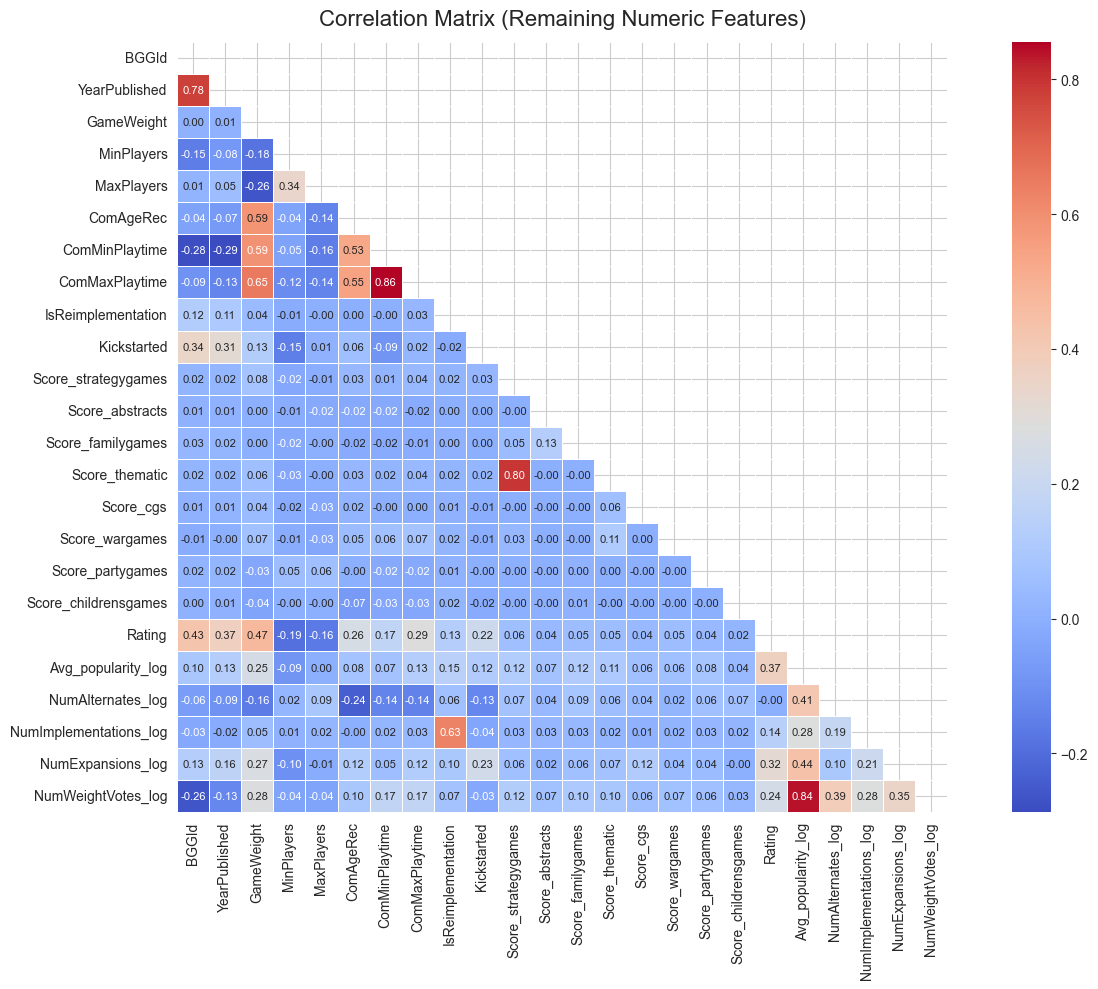

In [49]:
# 1. Select all numeric columns
numeric_df = df.select_dtypes(include="number")

# 2. Automatically exclude ALL columns starting with Cat: or Rank:
# This is to exclude old columns, if they haven't been completely dropped, 
# and to focus on the other numeric features.
cols_to_drop = [c for c in numeric_df.columns if c.startswith("Cat:") or c.startswith("Rank:")]
numeric_df = numeric_df.drop(columns=cols_to_drop, errors='ignore')

# 3. Correlation Matrix
corr_matrix = numeric_df.corr()

# 4. Upper triangle mask (to avoid redundancy in the plot)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Plot the heatmap
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix (Remaining Numeric Features)", fontsize=16, pad=12)
plt.tight_layout()
plt.show()

#### Saving the cleaned dataset 

In [50]:
# 1. Define the path: go up one level (..) and enter the dataset folder
file_path = "../dm1_25_26_dataset/cleaned_dataset.csv"

# 2. Save the CSV
df.to_csv(file_path, index=False)

print(f"File successfully saved in: {file_path}")

File successfully saved in: ../dm1_25_26_dataset/cleaned_dataset.csv


In [51]:
df

,BGGId,Name,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,ComMinPlaytime,ComMaxPlaytime,IsReimplementation,...,Score_cgs,Score_wargames,Score_partygames,Score_childrensgames,Rating,Avg_popularity_log,NumAlternates_log,NumImplementations_log,NumExpansions_log,NumWeightVotes_log
0,140386,Assassin's Creed: Arena,2014,1.8333,2,4,8.0,30.0,30.0,0,...,0.0,0.0,0.0,0.0,1,5.299983,0.000000,0.0,0.693147,1.945910
1,344114,Bag of Chips,2021,1.0000,2,5,8.0,15.0,20.0,0,...,0.0,0.0,0.0,0.0,2,3.799228,0.693147,0.0,0.000000,1.945910
2,319196,Gùgōng: Deluxe Big Box,2020,3.6667,1,5,10.0,30.0,150.0,0,...,0.0,0.0,0.0,0.0,3,5.744071,0.000000,0.0,0.693147,2.302585
3,11404,LetterFlip,2004,1.3077,2,2,7.0,20.0,20.0,0,...,0.0,0.0,0.0,0.0,1,4.013375,0.000000,0.0,0.000000,2.639057
4,281020,Treasures of Cibola,2019,1.5000,2,4,10.0,15.0,20.0,0,...,0.0,0.0,0.0,0.0,2,4.422849,1.386294,0.0,0.000000,1.098612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19724,3233,Ballast,1998,1.0000,2,4,8.0,15.0,15.0,0,...,0.0,0.0,0.0,0.0,1,3.721669,0.000000,0.0,0.000000,1.609438
19725,13359,Leapfrog,2004,1.5000,1,6,6.0,20.0,20.0,0,...,0.0,0.0,0.0,0.0,2,4.660289,1.098612,0.0,0.000000,2.833213
19726,3295,Athos,1993,1.6667,2,4,11.0,45.0,45.0,0,...,0.0,0.0,0.0,0.0,1,4.426841,0.000000,0.0,0.000000,1.386294
19727,176524,Hoplomachus: Origins,2015,3.0370,1,2,14.0,15.0,30.0,0,...,0.0,0.0,0.0,0.0,3,6.454150,0.000000,0.0,2.484907,3.332205
